# Defining CNN Model

In [1]:
# Load dependencies
import json
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np


### Building the Dataset from the COCO JSON annotation files

In [2]:
# Define the paths to be used

# This is my base project directory
BASE_DIR = r"C:\Users\danie\Desktop\1. Georgetown\1. Uni\4. NN\1. Project"

# This is where the dataset lives
DATA_DIR = os.path.join(BASE_DIR, "Data", "ShipRSImageNet_V1")



# COCO format annotation files for training and validation
TRAIN_JSON = os.path.join(DATA_DIR, "COCO_FORMAT", "ShipRSImageNet_bbox_train_level_1.json")
VAL_JSON   = os.path.join(DATA_DIR, "COCO_FORMAT", "ShipRSImageNet_bbox_val_level_1.json")


# VOC format image directory
IMG_DIR = os.path.join(DATA_DIR, "VOC_Format", "JPEGImages")

In [3]:
# Define a function to extract the labels from the COCO JSON files

# We will take one label per image, as we train on one level at a time
def coco_to_image_labels(coco_json):
    # open and parse JSON
    with open(coco_json) as f:
        data = json.load(f)

    # create mappings for images and assigned categories
    images = {img["id"]: img["file_name"] for img in data["images"]}
    categories = {cat["id"]: cat["name"] for cat in data["categories"]}

    # map image IDs to list of category IDs
    img_to_cats = {}
    for ann in data["annotations"]:
        img_to_cats.setdefault(ann["image_id"], []).append(ann["category_id"])

    # Build the dataframe to have one label per image per row
    records = []
    for img_id, fname in images.items():
        if img_id in img_to_cats:
            cat_ids = img_to_cats[img_id]
            main_cat = max(set(cat_ids), key=cat_ids.count)
            records.append({"filename": fname, "label": categories[main_cat]})
    return pd.DataFrame(records)


### Creating the Dataframes

In [4]:
# Run for train and val DFs
train_df = coco_to_image_labels(TRAIN_JSON)
val_df   = coco_to_image_labels(VAL_JSON)

- This returns a DF that holds each image (in its .bmp format name) and its associated class from the JSON annotations
- Each row is one image, and has its class (depending on the level that was used above) in its second column
- This is just the mappings, not the actual underlying data. That's why we only see the names 
- We can't feed text classes into the model
- Our classes are: ['Merchant' 'Other Ship' 'Warship' 'Dock']

In [5]:
# Inspect training
print(train_df.head(30))
print("Classes:", train_df["label"].unique())

               filename       label
0         100001606.bmp    Merchant
1         100001612.bmp  Other Ship
2            004387.bmp     Warship
3            004722.bmp        Dock
4            001888.bmp     Warship
5            004280.bmp     Warship
6            004543.bmp     Warship
7            004185.bmp     Warship
8         100000988.bmp    Merchant
9            001123.bmp  Other Ship
10     2278__0_1796.bmp    Merchant
11           004400.bmp    Merchant
12           004528.bmp     Warship
13  1467__2760_2219.bmp    Merchant
14           004572.bmp     Warship
15        100000930.bmp     Warship
16           003172.bmp     Warship
17           004695.bmp     Warship
18           004510.bmp     Warship
19           003236.bmp     Warship
20   1244__920_1840.bmp  Other Ship
21           003100.bmp     Warship
22           002333.bmp     Warship
23           004493.bmp     Warship
24           004361.bmp     Warship
25        100001149.bmp    Merchant
26  1467__2984_1840.bmp    M

### Define Pre-processing function

- We normalize, reshape, augment and transform to tensors

In [6]:
transform = transforms.Compose([
    transforms.Resize((224,224)),   # resizing
    transforms.RandomHorizontalFlip(),  # additional data augmentation
    transforms.ToTensor(),  # converting to tensor                              # https://docs.pytorch.org/vision/main/generated/torchvision.transforms.ToTensor.html
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])  # normalizing
])

Creating the Dataset function

- This defines the way in which we grab an image from the Image folder and access this specific image's mapping from the above DF
- Then, we also run the pre-processing steps, in which we also transform the images to tensors
- Just now, we get a DataSet object, that holds each image as a tensor, and their assigned class, also a tensor
- Each image tensor and class tensor is a row

In [7]:
class ShipImageDataset(Dataset):
    def __init__(self, df, image_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform
        self.classes = sorted(df["label"].unique())
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.image_dir, row["filename"])
        img = Image.open(img_path).convert("RGB")                               # Creates RGB pillow Image
        label = self.class_to_idx[row["label"]]                             
        if self.transform:                                                      # Applies the actual transformation from pillow Image to tensor
            img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.long)


Here, we now run all the functions above:

- Dataset function runs on the defined DataFrame

In [8]:
# Running the 


# We pass the dataframe, the image directory, and the pre-processing function to the call
train_ds = ShipImageDataset(train_df, IMG_DIR, transform)
val_ds   = ShipImageDataset(val_df, IMG_DIR, transform)

In [9]:
# Lets inspect the new Train and Val DataSets

print(type(train_ds))
print(type(val_ds))
print("Number of training samples:", len(train_ds))
print("Number of validation samples:", len(val_ds))


# For Test Set

print("Total samples:", len(train_ds))
print("Classes:", train_ds.classes)
print("Class → index mapping:", train_ds.class_to_idx)

<class '__main__.ShipImageDataset'>
<class '__main__.ShipImageDataset'>
Number of training samples: 2198
Number of validation samples: 550
Total samples: 2198
Classes: ['Dock', 'Merchant', 'Other Ship', 'Warship']
Class → index mapping: {'Dock': 0, 'Merchant': 1, 'Other Ship': 2, 'Warship': 3}


In [10]:
# Inspect one sample

# Grabbing image and label from the first row


img, label = train_ds[0]
print("Type of img:", type(img))
print("Shape of img:", img.shape)
print("Type of label:", type(label))
print("Value of label:", label)

print(f"We can see that the image is now a tensor, and the label is also a tensor")


Type of img: <class 'torch.Tensor'>
Shape of img: torch.Size([3, 224, 224])
Type of label: <class 'torch.Tensor'>
Value of label: tensor(1)
We can see that the image is now a tensor, and the label is also a tensor


### We can also inspect an example

We need to redo the normalization and show its associated label

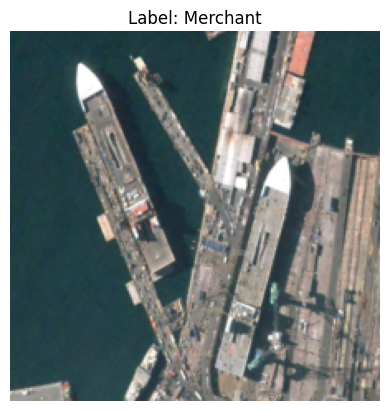

In [11]:
# Undo normalization for visualization
img_np = img.numpy().transpose(1, 2, 0)  # from [C,H,W] to [H,W,C]
img_np = (img_np * 0.5 + 0.5).clip(0, 1) # unnormalize from [-1,1] to [0,1]

plt.imshow(img_np)
plt.title(f"Label: {train_ds.classes[label.item()]}")
plt.axis("off")
plt.show()


## Just now, we actually have the RGB tensors for each image and its assiciated class 

## Now, we need to define a way how to load the data, when it is needed

### We use the standard PyTorch Dataloader for this: https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html

In [12]:
# We pass the DataSet objects to the DataLoader


# This is also where we define the batch size and whether to shuffle the training data
# After each batch, we update the model weights
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)
val_dl   = DataLoader(val_ds, batch_size=32)

## Gradient (direction of change)

- Gradient is the derivative of our Loss-function, with respect to the weights.
- It tells us how much and in what direction each weight affects the loss.
- If the gradient is positive, increasing the weight will increase the loss.
- If the gradient is negative, increasing the weight will decrease the loss.

**Gradient is the slope of the Loss Function with respect to the weights**

We update the weights after each batch, in opposite direction to their gradients.

## Batch and Epoch

- We run each batch size, say 32, as many times as we need to cover all images once
- That's one epoch

- The lower the batch size, the more batches per epoch
- The more batches, the more weight updates we do, after computing the gradients.

Weight updates for one full training run: (Batch number per epoch x num epochs)

## Lets look at one Batch:

In [13]:
imgs, labels = next(iter(train_dl))  # grabs the first batch
print("Batch shape:", imgs.shape)
print("Labels shape:", labels.shape)
print("Labels (as numbers):", labels.tolist())


Batch shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Labels (as numbers): [3, 3, 3, 0, 3, 1, 3, 3, 1, 2, 1, 1, 1, 1, 3, 3, 1, 1, 2, 3, 3, 3, 2, 1, 1, 3, 3, 3, 3, 3, 3, 3]


- We get 32 images at 3 x 224 x 224 each (hence the torch of dimension 32, 3, 244, 244)
- We get 32 labels 

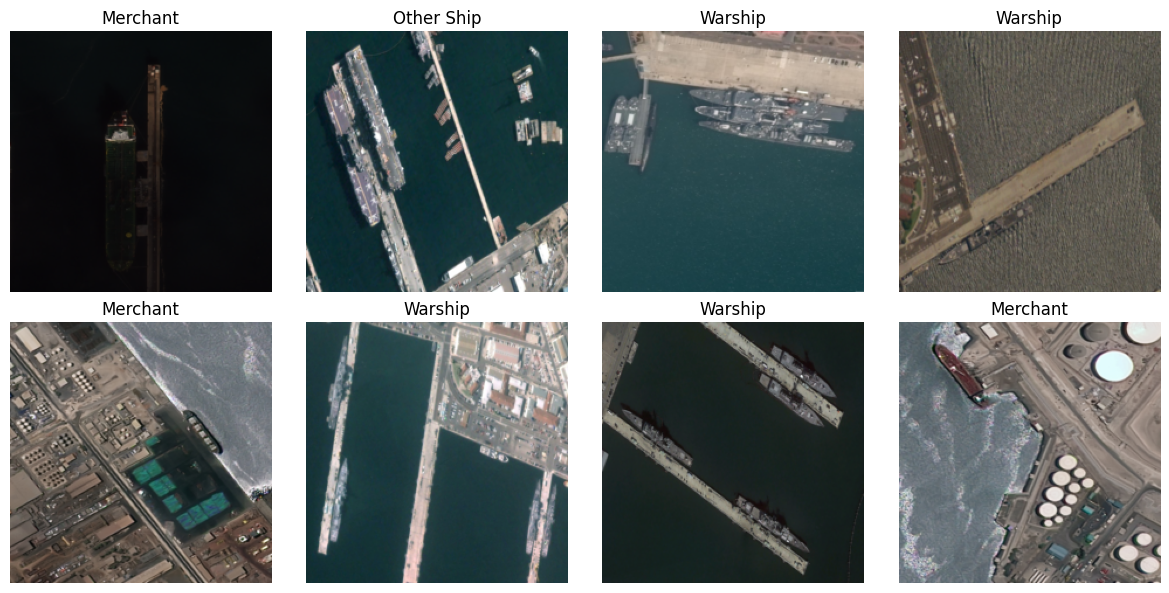

In [14]:
# Unnorma;ize and inspect some of the images and their labels
imgs, labels = next(iter(train_dl))

fig, axes = plt.subplots(2, 4, figsize=(12,6))
for i, ax in enumerate(axes.flat):
    img = imgs[i].numpy().transpose(1, 2, 0)        
    img = (img * 0.5 + 0.5).clip(0, 1)              
    ax.imshow(img)
    ax.set_title(f"{train_ds.classes[labels[i].item()]}")
    ax.axis("off")
plt.tight_layout()
plt.show()


# Define Our Model

https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html

We are now defining a classification CNN on the Level1 Data above

In [73]:
class Net(nn.Module):
    def __init__(self):                             # CONV LAYER SETUP: (Input channels (RGB), output channels (filter number), kernel size (filter size))
        super().__init__()
        self.conv1 = nn.Conv2d(3, 8, 3)             # First CONV LAYER: We will start out with 8 filters, at kernel size 3. So each filter will be 3 x 3 x 3
        self.pool1 = nn.MaxPool2d(2, 2)              # First POOLING LAYER: MaxPooling at 2 x 2
        self.conv2 = nn.Conv2d(8, 16, 3)            # Second CONV LAYER: Input channels = last lauyer's output channels, double to 16 filters, keep filter size
        self.pool2 = nn.MaxPool2d(2, 2)             # Second POOLING LAYER: MaxPooling at 2 x 2
        self.conv3 = nn.Conv2d(16, 32, 3)           # Third CONV LAYER: Input channels = last lauyer's output channels, double to 32 filters, keep filter size
        self.fc1 = nn.Linear(32 * 52 * 52, 4)
        
    def forward(self, x):                           # This is the forward pass step
        x = self.pool1(F.relu(self.conv1(x)))      # First CONV, RELU, POOL
        x = self.pool2(F.relu(self.conv2(x)))      # Second CONV, RELU, POOL
        x = F.relu(self.conv3(x))                  # Third CONV, RELU NO POOL since last layer 
        x = torch.flatten(x, 1)                     # Flatten all dimensions except batch
        x = self.fc1(x)                             # Fully connected layer
        return x

net = Net()

## Loss Function

In [74]:
criterion = nn.CrossEntropyLoss() # For multi-class classification


optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9) # Stochastic Gradient Descent to update weights after each batch
# Low learning rate and momentum to avoid overshooting, this will impact training time

## Initialize Training

In [75]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 3050 Ti Laptop GPU


In [76]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
net.to(device)
# Fitting just 10 epochs for now
num_epochs = 10


# Initialize empty lists for metrics
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# set up the training loop
for epoch in range(num_epochs):
    # set model to training 
    net.train()
    running_loss = 0.0
    correct = 0
    total = 0
    # for each batch, send data to device, zero gradients, forward pass, compute loss, backward pass, optimize
    for inputs, labels in train_dl:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # accumulate loss and accuracy
        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()
        
    # compute epoch loss and accuracy
    train_loss = running_loss / len(train_dl)
    train_acc = 100 * correct / total

    # set model to evaluation
    net.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    # 
    with torch.no_grad():
        for inputs, labels in val_dl:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = net(inputs)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (preds == labels).sum().item()

    val_loss = val_running_loss / len(val_dl)
    val_acc = 100 * val_correct / val_total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}]"
        f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%"
        f"  ||  Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")


Epoch [1/10]  Train Loss: 1.0033 | Train Acc: 56.78%  ||  Val Loss: 0.9004 | Val Acc: 63.45%


KeyboardInterrupt: 

Visualize the first Results

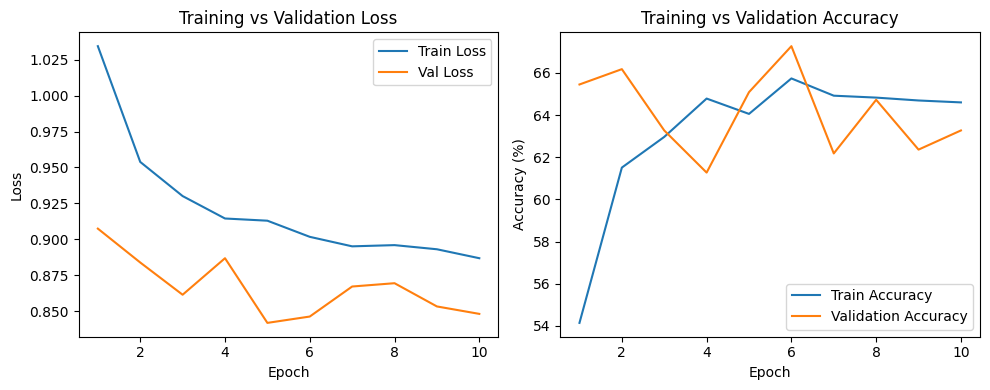

In [19]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Val Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, label="Train Accuracy")
plt.plot(epochs, val_accuracies, label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.tight_layout()
plt.show()


So far, this is a terrible model. However, it only incoporates 3 convolitiona layers and very little filters, so overall a very low number of trainable parameters, and only trains on 10 epochs.

# Second Model

# Try to establish Max Model and then Converge?

Increase Filters

30 Epochs?

Fully connected Dense

Dropout before fully connected

3x3 for F

In [15]:
class Net(nn.Module):
    """
    VGG-style CNN with double convolutions per block
    Expected improvement: ~77-80% val accuracy
    Slower training: ~2x longer
    """
    def __init__(self):
        super().__init__()
        
        # Block 1: Two 3x3 convs with 32 filters
        self.conv1a = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.bn1a = nn.BatchNorm2d(64)
        self.conv1b = nn.Conv2d(64, 64, kernel_size=3, padding=1) 
        self.bn1b = nn.BatchNorm2d(64)
        self.pool1 = nn.MaxPool2d(2, 2)
        
        # Block 2: Two 3x3 convs with 64 filters
        self.conv2a = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn2a = nn.BatchNorm2d(128)
        self.conv2b = nn.Conv2d(128, 128, kernel_size=3, padding=1) 
        self.bn2b = nn.BatchNorm2d(128)
        self.pool2 = nn.MaxPool2d(2, 2)
        
        # Block 3: Two 3x3 convs with 128 filters
        self.conv3a = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn3a = nn.BatchNorm2d(256)
        self.conv3b = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.bn3b = nn.BatchNorm2d(256)
        self.pool3 = nn.MaxPool2d(2, 2)

        
        # Global Average Pooling
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        # Classification head
        self.fc1 = nn.Linear(256, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 4)
        
        self._initialize_weights()
        
    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.constant_(m.bias, 0)
        
    def forward(self, x):
        # Block 1
        x = F.relu(self.bn1a(self.conv1a(x)))
        x = F.relu(self.bn1b(self.conv1b(x)))
        x = self.pool1(x)
        
        # Block 2
        x = F.relu(self.bn2a(self.conv2a(x)))
        x = F.relu(self.bn2b(self.conv2b(x)))
        x = self.pool2(x)
        
        # Block 3 (triple conv)
        x = F.relu(self.bn3a(self.conv3a(x)))
        x = F.relu(self.bn3b(self.conv3b(x)))
        x = self.pool3(x)

        # Classification
        x = self.global_pool(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

net_Max = Net()

In [16]:
# 1. Recreate model
net_Max = Net()  # Your properly defined Net class
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
net_Max.to(device)

# 2. Create fresh optimizer and criterion
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net_Max.parameters(), lr=0.0001)

In [ ]:
# 4. NOW train
num_epochs = 30
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

print("="*60)
print("TRAINING")
print("="*60 + "\n")

for epoch in range(num_epochs):
    net_Max.train() 
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in train_dl:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = net_Max(inputs) 
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()
        
    train_loss = running_loss / len(train_dl)
    train_acc = 100 * correct / total

    net_Max.eval()  
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for inputs, labels in val_dl:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = net_Max(inputs)  
            loss = criterion(outputs, labels)
            val_running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (preds == labels).sum().item()

    val_loss = val_running_loss / len(val_dl)
    val_acc = 100 * val_correct / val_total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch [{epoch+1:2d}/{num_epochs}]"
        f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:6.2f}%"
        f"  ||  Val Loss: {val_loss:.4f} | Val Acc: {val_acc:6.2f}%")

TRAINING

Epoch [ 1/30]  Train Loss: 1.0965 | Train Acc:  57.32%  ||  Val Loss: 0.8400 | Val Acc:  65.82%


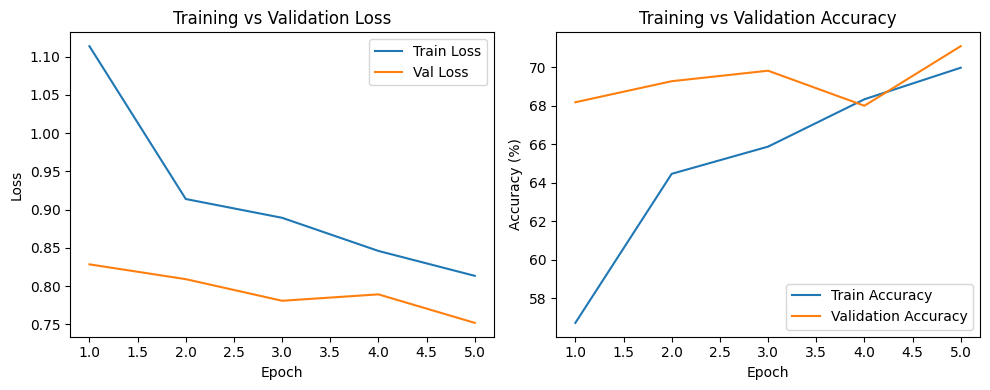

In [49]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Val Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, label="Train Accuracy")
plt.plot(epochs, val_accuracies, label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.tight_layout()
plt.show()


In [57]:
import torch

print("="*60)
print("GPU DIAGNOSTIC")
print("="*60)

# Check CUDA availability
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")
    print(f"GPU device count: {torch.cuda.device_count()}")
    print(f"Current GPU: {torch.cuda.current_device()}")
    print(f"GPU name: {torch.cuda.get_device_name(0)}")
    print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("⚠️ CUDA is NOT available!")
    print("PyTorch will use CPU")

GPU DIAGNOSTIC
PyTorch version: 2.5.1+cu121
CUDA available: True
CUDA version: 12.1
GPU device count: 1
Current GPU: 0
GPU name: NVIDIA GeForce RTX 3050 Ti Laptop GPU
GPU memory: 4.29 GB
